# Assignment #4: A simple language classifier with scikit-learn and PyTorch


Author: Pierre Nugues


## Objectives


In this assignment, you will implement a language detector inspired and simplified from Google's _Compact language detector_, version 3 (CLD3): https://github.com/google/cld3. CLD3 is written in C++ and its code is available from GitHub. CLD3 can scale to many languages and complemented with other techniques as you can read here: https://arxiv.org/pdf/2205.03983

The objectives of the assignment are to:

- Write a program to classify languages
- Use neural networks with sklearn and PyTorch
- Understand how to evaluate a classifier
- Write a short individual report of 2 to 3 pages to describe your program.

The outline of the lab is:

1. You will first collect and preprocess a dataset;
2. You will create a language classifier using sklearn, an easy-to-use API. This should enable you to understand the concepts with a top-down approach as you will have less details to manage;
3. You will reimplement the classifier using PyTorch, a deep-learning API, where you will write the gradient descent loop explicitly;
4. In both experiments, you will evaluate your classification results.


## Description


### System Overview


Read the GitHub description of CLD3, https://github.com/google/cld3, (_Model_ section). In your individual report, you will summarize it in two or three sentences in the _Method and program structure_ section.


## Imports


In [71]:
import bz2
import json
import os
import numpy as np
import requests
import sys
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import hashlib
from tqdm import tqdm
import regex as re
import joblib
from collections import Counter

In [72]:
random.seed(1234)
np.random.seed(1234)
torch.manual_seed(1234)

## Dataset


As dataset, we will use Tatoeba, https://tatoeba.org/eng/downloads. It consists of more than 12 million short texts in more than 400 languages and it is available in one file called `sentences.csv`.

The dataset is structured this way: There is one text per line, where each line consists of the three following fields separated by tabulations and ended by a carriage return:

```
sentence id [tab] language code [tab] text [cr]
```

Each text (sentence) has a unique id and has a language code that follows the ISO 639-3 standard (see below).


### Scope of the lab


In this lab, you will consider six languages only: French (fra), Japanese (jpn), Chinese (cmn), English (eng), Swedish (swe), and Danish (dan). Below is an excerpt of the Tatoeba dataset limited to three languages:

```
1276    eng     Let's try something.
1277    eng     I have to go to sleep.
1280    eng     Today is June 18th and it is Muiriel's birthday!
...
1115    fra     Lorsqu'il a demandé qui avait cassé la fenêtre, tous les garçons ont pris un air innocent.
1279    fra     Je ne supporte pas ce type.
1441    fra     Pour une fois dans ma vie je fais un bon geste... Et ça ne sert à rien.
...
337413  swe     Vi trodde att det var ett flygande tefat.
341910  swe     Detta är huset jag bodde i när jag var barn.
341938  swe     Vi hade roligt på stranden igår.
...
```

Tatoeba is updated continuously. The examples from this dataset come from a corpus your instructor downloaded on September 17, 2024.


## Getting the Dataset


Before you start programming the rest, download the Tatoeba dataset. You can use the instructions (uncomment them):


In [73]:
#!wget https://downloads.tatoeba.org/exports/sentences.tar.bz2

In [74]:
#!tar -xvjf sentences.tar.bz2

### Loading the Dataset


Run the code to read the dataset and split it into lines. You may have to change the path


In [75]:
dataset_large = open('sentences.csv', encoding='utf8').read().strip()
dataset_large = dataset_large.split('\n')
dataset_large[:10]

['1\tcmn\t我們試試看！',
 '2\tcmn\t我该去睡觉了。',
 '3\tcmn\t你在干什麼啊？',
 '4\tcmn\t這是什麼啊？',
 '5\tcmn\t今天是６月１８号，也是Muiriel的生日！',
 '6\tcmn\t生日快乐，Muiriel！',
 '7\tcmn\tMuiriel现在20岁了。',
 '8\tcmn\t密码是"Muiriel"。',
 '9\tcmn\t我很快就會回來。',
 '10\tcmn\t我不知道。']

The size may vary as new documents are added every day to _Tatoeba_


In [76]:
len(dataset_large)

13013893

Run the code to split the fields and remove possible whitespaces


In [77]:
dataset_large = list(map(lambda x: tuple(x.split('\t')), dataset_large))
dataset_large = list(map(lambda x: tuple(map(str.strip, x)), dataset_large))
dataset_large[:3]

[('1', 'cmn', '我們試試看！'), ('2', 'cmn', '我该去睡觉了。'), ('3', 'cmn', '你在干什麼啊？')]

In [78]:
counter = Counter(map(lambda x: x[1], dataset_large))

Again the figures may vary


In [79]:
counter.most_common(30)

[('eng', 1994102),
 ('rus', 1156129),
 ('ita', 944469),
 ('epo', 798465),
 ('kab', 772984),
 ('tur', 740628),
 ('deu', 736378),
 ('ber', 693672),
 ('fra', 688340),
 ('por', 438056),
 ('hun', 422909),
 ('spa', 421384),
 ('jpn', 246597),
 ('heb', 209894),
 ('nld', 194094),
 ('ukr', 187669),
 ('fin', 152489),
 ('lit', 136598),
 ('pol', 133418),
 ('ces', 84791),
 ('mar', 80024),
 ('cmn', 78529),
 ('mkd', 78253),
 ('tgl', 76787),
 ('tok', 68733),
 ('ara', 67019),
 ('dan', 65980),
 ('swe', 56309),
 ('lat', 52747),
 ('tat', 51965)]

In [80]:
len(counter)

428

## Understanding the ${X}$ matrix (feature matrix)

You will now investigate the CLD3 features. In your report, you will describe the features CLD3 extracts from each text.


Write a program to create a simplified ${X}$ matrix where you will represent the 9 texts with CLD3 features. You will use a restricted set of features: You will only consider the letters _a_, _b_, and _n_ and the bigrams _an_, _ba_, and _na_. You will ignore the the rest of letters and bigrams as well as the trigrams. Your matrix will have 9 rows and 6 columns, each column will contain these counts: `[#a, #b, #n, #an, #ba, #na]`.

The CLD3's original description uses relative frequencies (counts of a letter divided by the total counts of letters in the text). Here, you will use the raw counts.

To help you start your program to extract the counts, you can use the `str.count()` function


In [81]:
example_ngrams = ['a', 'b', 'n', 'an', 'ba', 'na']

In [82]:
"""Lorsqu'il a demandé qui avait cassé la fenêtre, tous les garçons ont pris un air innocent.""".count(
    'a')

8

In [83]:
"""Lorsqu'il a demandé qui avait cassé la fenêtre, tous les garçons ont pris un air innocent.""".count(
    'an')

1

In [84]:
my_string = """Lorsqu'il a demandé qui avait cassé la fenêtre, tous les garçons ont pris un air innocent."""
row = []
for ngram in example_ngrams:
    row += [my_string.count(ngram)]
row

[8, 0, 8, 1, 0, 0]

The indices of the test sentences


In [85]:
test_idx = list(
    map(str, [1276, 1277, 1280, 1115, 1279, 1441, 337413, 341910, 341938]))
test_idx

['1276', '1277', '1280', '1115', '1279', '1441', '337413', '341910', '341938']

Write the code to extract the feature matrix from the test sentences as well as the languages.
You will store the features in an $X$ matrix and the languages in an $\mathbf{y}$ vector.
You will **include this matrix in your report** in the _Method and program structure section_.


In [86]:
# Write your code here
X = []
y = []

for line in dataset_large:
    idx, lang, sentence = line
    if idx in test_idx:
        print(line)
        y.append(lang)
        row = []
        for ngram in example_ngrams:
            row += [sentence.count(ngram)]
        X.append(row)
    
X, y

('1115', 'fra', "Lorsqu'il a demandé qui avait cassé la fenêtre, tous les garçons ont pris un air innocent.")
('1276', 'eng', "Let's try something.")
('1277', 'eng', 'I have to go to sleep.')
('1279', 'fra', 'Je ne supporte pas ce type.')
('1280', 'eng', "Today is June 18th and it is Muiriel's birthday!")
('1441', 'fra', 'Pour une fois dans ma vie je fais un bon geste... Et ça ne sert à rien.')
('337413', 'swe', 'Vi trodde att det var ett flygande tefat.')
('341910', 'swe', 'Detta är huset jag bodde i när jag var barn.')
('341938', 'swe', 'Vi hade roligt på stranden igår.')


([[8, 0, 8, 1, 0, 0],
  [0, 0, 1, 0, 0, 0],
  [1, 0, 0, 0, 0, 0],
  [1, 0, 1, 0, 0, 0],
  [3, 1, 2, 1, 0, 0],
  [4, 1, 6, 1, 0, 0],
  [4, 0, 1, 1, 0, 0],
  [5, 2, 2, 0, 1, 0],
  [2, 0, 2, 1, 0, 0]],
 ['fra', 'eng', 'eng', 'fra', 'eng', 'fra', 'swe', 'swe', 'swe'])

## Restricting the Dataset to a few Languages


The Tatoeba dataset is very large. You will first extract a subset of it

Write the code to extract texts in the languages below. For each language, you limit the number of documents to 25,000 or less if the language has less documents.
You will call the resulting dataset: `dataset`


The languages


In [87]:
langs = ['ara', 'fra', 'cmn', 'jpn', 'kor', 'eng', 'swe', 'dan']

The maximal number of documents per language. If this number is too large for your computer, please use a smaller one, for instance 15,000.


In [88]:
MAX_DOCS = 25000

Write a loop that:

1. Extracts a list of all the documents in a certain language from the dataset
2. Shuffles this list with `random.shuffle()`
3. Adds `MAX_DOCS` to `dataset`. You just need to use a slice


In [124]:
# Write your code here
dataset = []
for lang in langs:
    lang_docs = list(filter(lambda x: x[1] == lang, dataset_large))
    dataset += lang_docs[:MAX_DOCS]

In [128]:
random.shuffle(dataset)

In [129]:
len(dataset)

189257

In [130]:
dataset[:5]

[('13201676', 'kor', '일론 머스크는 나치예요.'),
 ('94996', 'jpn', '彼女にはなにかとりえがありますか。'),
 ('80752', 'jpn', '命のある間は希望がある。'),
 ('2603118', 'ara', 'هذه المنطقة مدمّرة.'),
 ('76699', 'jpn', 'さすが、お嬢様。自由奔放な生活をしていたわけじゃないんだ。')]

## Utilities

Before you can use the dataset to train a model, you need to convert it into numbers. You will carry this with out the following steps and you will write a corresponding function.

1. You will extract the $n$-grams up to trigrams (`all_ngrams()`);
2. Trigrams can create many symbols that most student's machines cannot process. You will reduce their numbers using hash codes (`hash_ngrams()`);
3. You will compute the relative frequencies of the $n$-grams, replaced here by the hash codes (`calc_ref_freq()`).
4. The results will be stored in three dictionaries, for characters, bigrams, and trigrams. You will merge these dictionaries into one (`shift_keys()`).

You will then apply the functions to vectorize the dataset.


### Extracting $n$-grams

The goal of this section is that you extract the $n$-grams from a text. By default, you will lowercase the text. The result will have the form: `[chars, bigrams, trigrams]`


Write a function to extract the $n$-grams of a sentence: `ngrams(sentence, n=1, lc=True)`, `n` is a parameters. You can use list slices for this.


In [131]:
# Write your code here
def ngrams(sentence, n=1, lc=True):
    ngram_l = []
    if lc:
        sentence = sentence.lower()

    for i in range(len(sentence) - n + 1):
        ngram_l.append(sentence[i:i+n])

    return ngram_l

In [132]:
ngrams('try something.')

['t', 'r', 'y', ' ', 's', 'o', 'm', 'e', 't', 'h', 'i', 'n', 'g', '.']

In [133]:
ngrams('try something.', n=2)

['tr', 'ry', 'y ', ' s', 'so', 'om', 'me', 'et', 'th', 'hi', 'in', 'ng', 'g.']

We now use this function to extract all the $n$-grams


In [134]:
def all_ngrams(sentence, max_ngram=3, lc=True):
    all_ngram_list = []
    for i in range(1, max_ngram + 1):
        all_ngram_list += [ngrams(sentence, n=i, lc=lc)]
    return all_ngram_list

In [135]:
all_ngrams('try something.')

[['t', 'r', 'y', ' ', 's', 'o', 'm', 'e', 't', 'h', 'i', 'n', 'g', '.'],
 ['tr',
  'ry',
  'y ',
  ' s',
  'so',
  'om',
  'me',
  'et',
  'th',
  'hi',
  'in',
  'ng',
  'g.'],
 ['try',
  'ry ',
  'y s',
  ' so',
  'som',
  'ome',
  'met',
  'eth',
  'thi',
  'hin',
  'ing',
  'ng.']]

### Hashing


We consider languages with many characters that will make the number of bigrams and trigrams impossible to process. We will use the _hashing trick_ to reduce them, where we will gather $n$-grams into subsets using hash codes.

Each item will have this format:
`[char_hcodes, bigram_hcodes, trigram_hcodes]`.


#### Description


Python has a built-in hashing function that returns a unique numerical signature for a given string


In [137]:
hash('a'), hash('ab'), hash('abc')

(5873856766078682237, -647725380073708235, 6806390625921358980)

If we take the remainder (modulo) of a division by 5, we reduce the possible codes to: 0, 1, 2, 3, or 4


In [142]:
list(map(lambda x: x % 5, (hash('a'), hash('ab'), hash('abc'))))

[2, 0, 0]

#### Implementation


We set maximal numbers for our $n$-grams using these divisors


In [143]:
MAX_CHARS = 521
MAX_BIGRAMS = 1031
MAX_TRIGRAMS = 1031

Here strings have integer codes within the range [0, `MAX_CHARS`[


In [145]:
list(map(lambda x: x % MAX_CHARS, (hash('a'), hash('ab'), hash('abc'))))

[168, 141, 133]

Hash codes may vary across machines and Marcus Klang wrote this function to have reproducible codes


In [147]:
def reproducible_hash(string):
    """
    reproducible hash on any string

    Arguments:
       string: python string object

    Returns:
       signed int64
    """

    # We are using MD5 for speed not security.
    h = hashlib.md5(string.encode("utf-8"), usedforsecurity=False)
    return int.from_bytes(h.digest()[0:8], 'big', signed=True)

In [148]:
reproducible_hash('a')

919145239626757800

In [149]:
reproducible_hash('a') % MAX_CHARS

234

### Converting $n$-grams to hash codes

You will now convert the $n$-grams to hash codes


In [150]:
MAXES = [MAX_CHARS, MAX_BIGRAMS, MAX_TRIGRAMS]

Create a `hash_ngrams` function that creates a list of hash codes from a list of $n$-grams. As arguments, you will have the list of $n$-grams `[chars, bigrams, trigrams]` as well as the list of dividers (`MAXES`).

The output format will be a list of three lists:

`[char_hcodes, bigram_hcodes, trigram_hcodes]`.


In [168]:
# Write your code
def hash_ngrams(ngrams: list[list[str]], modulos: list[int]) -> list[list[int]]:
    hash_codes = []
    for ngram in ngrams:
        codes = []
        for s in ngram:
            n = len(s)
            hash_code = reproducible_hash(s) % modulos[n - 1]
            codes.append(hash_code)
        hash_codes.append(codes)
    return hash_codes

In [169]:
all_ngrams('try something.')

[['t', 'r', 'y', ' ', 's', 'o', 'm', 'e', 't', 'h', 'i', 'n', 'g', '.'],
 ['tr',
  'ry',
  'y ',
  ' s',
  'so',
  'om',
  'me',
  'et',
  'th',
  'hi',
  'in',
  'ng',
  'g.'],
 ['try',
  'ry ',
  'y s',
  ' so',
  'som',
  'ome',
  'met',
  'eth',
  'thi',
  'hin',
  'ing',
  'ng.']]

In [170]:
hash_ngrams(all_ngrams('try something.'), MAXES)

[[432, 437, 309, 86, 331, 97, 100, 32, 432, 332, 233, 310, 31, 442],
 [6, 765, 224, 203, 557, 176, 590, 711, 527, 757, 919, 57, 685],
 [848, 617, 468, 456, 873, 996, 287, 10, 817, 674, 960, 399]]

### Functions to Count Hash Codes


Write a function `calc_rel_freq(codes)` to count the codes. As in CLD3, you will return the relative frequencies.

This is just an application of `Counter` to a list of codes and then a division by the length.

The input is a list of codes and the output is a `Counter` object of relative frequencies.


In [173]:
# Write your code
def calc_rel_freq(codes):
    cnt = Counter(codes)
    total = sum(cnt.values())
    for k in cnt:
        cnt[k] /= total
    return cnt

In [174]:
hash_ngrams(all_ngrams('try something.'), MAXES)

[[432, 437, 309, 86, 331, 97, 100, 32, 432, 332, 233, 310, 31, 442],
 [6, 765, 224, 203, 557, 176, 590, 711, 527, 757, 919, 57, 685],
 [848, 617, 468, 456, 873, 996, 287, 10, 817, 674, 960, 399]]

In [175]:
list(map(calc_rel_freq, hash_ngrams(all_ngrams('try something.'), MAXES)))

[Counter({432: 0.14285714285714285,
          437: 0.07142857142857142,
          309: 0.07142857142857142,
          86: 0.07142857142857142,
          331: 0.07142857142857142,
          97: 0.07142857142857142,
          100: 0.07142857142857142,
          32: 0.07142857142857142,
          332: 0.07142857142857142,
          233: 0.07142857142857142,
          310: 0.07142857142857142,
          31: 0.07142857142857142,
          442: 0.07142857142857142}),
 Counter({6: 0.07692307692307693,
          765: 0.07692307692307693,
          224: 0.07692307692307693,
          203: 0.07692307692307693,
          557: 0.07692307692307693,
          176: 0.07692307692307693,
          590: 0.07692307692307693,
          711: 0.07692307692307693,
          527: 0.07692307692307693,
          757: 0.07692307692307693,
          919: 0.07692307692307693,
          57: 0.07692307692307693,
          685: 0.07692307692307693}),
 Counter({848: 0.08333333333333333,
          617: 0.08333333333333

### Merge the Dictionaries


In the results above, we have three counter objects with numerical keys (the hash codes). You will build one dictionary of them.

There is a key overlap and we must take care that a same hash code for the unigrams is not the same as in the bigrams. We will then shift the keys.

The keys range from:

1. Unigrams from 0 to 521, [0, MAX_CHARS[
2. Bigrams from 0 to 1031, [0, MAX_BIGRAMS[
3. Trigrams from 1 to 1031, [0, MAX_TRIGRAMS[


You will leave the unigrams keys as they are. You will shift the bigram keys by MAX_CHARS, and the trigram keys by MAX_CHARS + MAX_BIGRAMS. You can reuse the code below


In [176]:
MAX_SHIFT = []
for i in range(len(MAXES)):
    MAX_SHIFT += [sum(MAXES[:i])]

In [177]:
MAX_SHIFT

[0, 521, 1552]

Write a `shift_keys(dicts, MAX_SHIFT)` function that takes a list of dictionaries as input and the list of shifts and that a new unique dictionary, where the numerical keys have been shifted by the numbers in `MAX_SHIFT`


In [178]:
# Write your code here
def shift_keys(dicts, MAX_SHIFT):
    new_dict = {}
    for i, ngrams_d in enumerate(dicts):
        for k, v in ngrams_d.items():
            new_dict[k + MAX_SHIFT[i]] = v
    return new_dict

In [179]:
list(map(calc_rel_freq, hash_ngrams(all_ngrams('try something.'), MAXES)))

[Counter({432: 0.14285714285714285,
          437: 0.07142857142857142,
          309: 0.07142857142857142,
          86: 0.07142857142857142,
          331: 0.07142857142857142,
          97: 0.07142857142857142,
          100: 0.07142857142857142,
          32: 0.07142857142857142,
          332: 0.07142857142857142,
          233: 0.07142857142857142,
          310: 0.07142857142857142,
          31: 0.07142857142857142,
          442: 0.07142857142857142}),
 Counter({6: 0.07692307692307693,
          765: 0.07692307692307693,
          224: 0.07692307692307693,
          203: 0.07692307692307693,
          557: 0.07692307692307693,
          176: 0.07692307692307693,
          590: 0.07692307692307693,
          711: 0.07692307692307693,
          527: 0.07692307692307693,
          757: 0.07692307692307693,
          919: 0.07692307692307693,
          57: 0.07692307692307693,
          685: 0.07692307692307693}),
 Counter({848: 0.08333333333333333,
          617: 0.08333333333333

In [180]:
shift_keys(map(calc_rel_freq, hash_ngrams(
    all_ngrams('try something.'), MAXES)), MAX_SHIFT)

{432: 0.14285714285714285,
 437: 0.07142857142857142,
 309: 0.07142857142857142,
 86: 0.07142857142857142,
 331: 0.07142857142857142,
 97: 0.07142857142857142,
 100: 0.07142857142857142,
 32: 0.07142857142857142,
 332: 0.07142857142857142,
 233: 0.07142857142857142,
 310: 0.07142857142857142,
 31: 0.07142857142857142,
 442: 0.07142857142857142,
 527: 0.07692307692307693,
 1286: 0.07692307692307693,
 745: 0.07692307692307693,
 724: 0.07692307692307693,
 1078: 0.07692307692307693,
 697: 0.07692307692307693,
 1111: 0.07692307692307693,
 1232: 0.07692307692307693,
 1048: 0.07692307692307693,
 1278: 0.07692307692307693,
 1440: 0.07692307692307693,
 578: 0.07692307692307693,
 1206: 0.07692307692307693,
 2400: 0.08333333333333333,
 2169: 0.08333333333333333,
 2020: 0.08333333333333333,
 2008: 0.08333333333333333,
 2425: 0.08333333333333333,
 2548: 0.08333333333333333,
 1839: 0.08333333333333333,
 1562: 0.08333333333333333,
 2369: 0.08333333333333333,
 2226: 0.08333333333333333,
 2512: 0.08333

Finally, we assemble all these utilities in a function


In [181]:
def build_freq_dict(sentence, MAXES=MAXES, MAX_SHIFT=MAX_SHIFT):
    hngrams = hash_ngrams(all_ngrams(sentence), MAXES)
    fhcodes = map(calc_rel_freq, hngrams)
    return shift_keys(fhcodes, MAX_SHIFT)

In [182]:
build_freq_dict('try something.')

{432: 0.14285714285714285,
 437: 0.07142857142857142,
 309: 0.07142857142857142,
 86: 0.07142857142857142,
 331: 0.07142857142857142,
 97: 0.07142857142857142,
 100: 0.07142857142857142,
 32: 0.07142857142857142,
 332: 0.07142857142857142,
 233: 0.07142857142857142,
 310: 0.07142857142857142,
 31: 0.07142857142857142,
 442: 0.07142857142857142,
 527: 0.07692307692307693,
 1286: 0.07692307692307693,
 745: 0.07692307692307693,
 724: 0.07692307692307693,
 1078: 0.07692307692307693,
 697: 0.07692307692307693,
 1111: 0.07692307692307693,
 1232: 0.07692307692307693,
 1048: 0.07692307692307693,
 1278: 0.07692307692307693,
 1440: 0.07692307692307693,
 578: 0.07692307692307693,
 1206: 0.07692307692307693,
 2400: 0.08333333333333333,
 2169: 0.08333333333333333,
 2020: 0.08333333333333333,
 2008: 0.08333333333333333,
 2425: 0.08333333333333333,
 2548: 0.08333333333333333,
 1839: 0.08333333333333333,
 1562: 0.08333333333333333,
 2369: 0.08333333333333333,
 2226: 0.08333333333333333,
 2512: 0.08333

## Converting the Dataset

We can now enrich the dataset with a numerical representation of the sentence. We use the utility functions and we call this new version: `dataset_num`


In [183]:
dataset[:2]

[('13201676', 'kor', '일론 머스크는 나치예요.'), ('94996', 'jpn', '彼女にはなにかとりえがありますか。')]

In [184]:
dataset_num = []
for datapoint in tqdm(dataset):
    dataset_num += [list(datapoint) + [build_freq_dict(datapoint[2])]]

100%|██████████| 189257/189257 [00:29<00:00, 6311.52it/s]


In [185]:
dataset_num[:2]

[['13201676',
  'kor',
  '일론 머스크는 나치예요.',
  {131: 0.07692307692307693,
   172: 0.07692307692307693,
   86: 0.23076923076923078,
   318: 0.07692307692307693,
   186: 0.07692307692307693,
   112: 0.07692307692307693,
   23: 0.07692307692307693,
   207: 0.07692307692307693,
   167: 0.07692307692307693,
   287: 0.07692307692307693,
   442: 0.07692307692307693,
   679: 0.08333333333333333,
   542: 0.08333333333333333,
   627: 0.08333333333333333,
   746: 0.08333333333333333,
   1298: 0.08333333333333333,
   1319: 0.08333333333333333,
   1155: 0.08333333333333333,
   1506: 0.08333333333333333,
   705: 0.08333333333333333,
   737: 0.08333333333333333,
   1401: 0.08333333333333333,
   569: 0.08333333333333333,
   2539: 0.09090909090909091,
   1807: 0.09090909090909091,
   2344: 0.09090909090909091,
   2015: 0.09090909090909091,
   1776: 0.09090909090909091,
   2497: 0.09090909090909091,
   1997: 0.09090909090909091,
   1981: 0.09090909090909091,
   1765: 0.09090909090909091,
   1879: 0.0909090

## Programming: Building ${X}$


You will now build the ${X}$ matrix.


### Vectorizing the features


The CLD3 architecture uses embeddings. In this lab, we will simplify it and we will use a feature vector instead consisting of the character frequencies. For example, you will represent the text:

`"Let's try something."`

with:

`{'l': 0.05, 'e': 0.1, 't': 0.15, "'": 0.05, 's': 0.1, ' ': 0.1, 
 'r': 0.05, 'y': 0.05, 'o': 0.05, 'm': 0.05, 'h': 0.05, 'i': 0.05, 
 'n': 0.05, 'g': 0.05, '.': 0.05}`

Note that we used characters and not codes to make it more legible.

To create the ${X}$ matrix, we need to transform the dictionaries of `dataset_num` into numerical vectors. The `DictVectorizer` class from the scikit-learn library, see here [https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.DictVectorizer.html], has two methods, `fit()` and `transform()`, and a combination of both `fit_transform()` to convert dictionaries into such vectors.


You will now write the code to:

1. Extract the hash code frequency dictionaries from `dataset_num` corresponding to its 3rd index;
2. Convert the list of dictionaries into an ${X}$ matrix using `DictVectorizer`.


#### Extracting the character frequencies


Produce a new list of datapoints with the unigrams only. Each item in this list will be a dictionary. You will call it `X_cat`


In [ ]:
# Write your code here

X_cat = [datapoint[3] for datapoint in dataset_num]

In [204]:
X_cat[0]

{131: 0.07692307692307693,
 172: 0.07692307692307693,
 86: 0.23076923076923078,
 318: 0.07692307692307693,
 186: 0.07692307692307693,
 112: 0.07692307692307693,
 23: 0.07692307692307693,
 207: 0.07692307692307693,
 167: 0.07692307692307693,
 287: 0.07692307692307693,
 442: 0.07692307692307693,
 679: 0.08333333333333333,
 542: 0.08333333333333333,
 627: 0.08333333333333333,
 746: 0.08333333333333333,
 1298: 0.08333333333333333,
 1319: 0.08333333333333333,
 1155: 0.08333333333333333,
 1506: 0.08333333333333333,
 705: 0.08333333333333333,
 737: 0.08333333333333333,
 1401: 0.08333333333333333,
 569: 0.08333333333333333,
 2539: 0.09090909090909091,
 1807: 0.09090909090909091,
 2344: 0.09090909090909091,
 2015: 0.09090909090909091,
 1776: 0.09090909090909091,
 2497: 0.09090909090909091,
 1997: 0.09090909090909091,
 1981: 0.09090909090909091,
 1765: 0.09090909090909091,
 1879: 0.09090909090909091,
 1950: 0.09090909090909091}

#### Vectorize `X_cat`


Convert you `X_cat` matrix into a numerical representation using `DictVectorizer`: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.DictVectorizer.html. You will set the `sparse` argument to `False` as PyTorch only accepts such matrices. Call the result `X`. If the matrices are too large for your machine, lower the size of the dataset.

Note that PyTorch may support sparse matrices in the future: https://pytorch.org/docs/stable/sparse.html. For now it is a beta feature.


In [205]:
# Write your code here
vectorizer = DictVectorizer(sparse=False)
X = vectorizer.fit_transform(X_cat)

In [206]:
X.shape

(189257, 2583)

In [207]:
X[:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## Programming: Building $\mathbf{y}$


You will now convert the list of language symbols into a $\mathbf{y}$ vector


Extract the language symbols from `dataset_small_feat` and call the resulting list `y_cat`


In [208]:
# Write your code here
y_cat = [datapoint[1] for datapoint in dataset_num]

In [210]:
y_cat[:5]

['kor', 'jpn', 'jpn', 'ara', 'jpn']

Extract the set of language symbols and name it `y_symbols`. Then build two indices mapping the symbols to integers and the integers to symbols. Both indices will be dictionaries that you will call: `lang2idx`and `idx2lang`. Such a conversion is not necessary with sklearn. We do it because many other many machine-learning toolkits (keras or pytorch) require a numerical $\mathbf{y}$ vector and to learn how to carry out this conversion.


In [223]:
# Write your code here
y_symbols = list(set(y_cat))
idx2lang = {i: lang for i, lang in enumerate(y_symbols)}
lang2idx = {lang: i for i, lang in idx2lang.items()}

In [224]:
idx2lang

{0: 'kor',
 1: 'ara',
 2: 'eng',
 3: 'swe',
 4: 'cmn',
 5: 'dan',
 6: 'fra',
 7: 'jpn'}

In [225]:
lang2idx

{'kor': 0,
 'ara': 1,
 'eng': 2,
 'swe': 3,
 'cmn': 4,
 'dan': 5,
 'fra': 6,
 'jpn': 7}

Convert your `y_cat` vector into a numerical vector. Call this vector `y`.


In [228]:
# Write your code here
y = [lang2idx[lang] for lang in y_cat]

In [229]:
y[:5]

[0, 7, 7, 1, 7]

## Programming: Building the Model


Create a neural network using sklearn with a hidden layer of 50 nodes and a relu activation layer: https://scikit-learn.org/stable/modules/neural_networks_supervised.html. Set the maximal number of iterations to 5, in the beginning, and verbose to True. Use the default values for the rest. You will call your classifier `clf`


In [235]:
# Write your code here

clf = MLPClassifier(hidden_layer_sizes=(50,), activation='relu', max_iter=5, verbose=True)

In [236]:
clf

MLPClassifier(hidden_layer_sizes=(50,), max_iter=5, verbose=True)

### Training and Validation Sets


You will now split the dataset into a training and validation sets


#### We split the dataset

We use a training set of 80% and a validation set of 20%


In [237]:
training_examples = int(X.shape[0] * 0.8)

X_train = X[:training_examples, :]
y_train = y[:training_examples]

X_val = X[training_examples:, :]
y_val = y[training_examples:]

### Fitting the model


Fit the model on the training set


In [238]:
# Write your code here
model = clf.fit(X_train, y_train)

Iteration 1, loss = 0.47790808
Iteration 2, loss = 0.05088719
Iteration 3, loss = 0.03045572
Iteration 4, loss = 0.02275308
Iteration 5, loss = 0.01853896


/Users/johanekberg/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


## Predicting


Predict the `X_val` languages. You will call the result `y_val_pred`


In [239]:
# Write your code here
y_val_pred = model.predict(X_val)

In [240]:
y_val_pred[:20]

array([6, 7, 2, 7, 0, 3, 2, 5, 4, 5, 4, 4, 3, 4, 2, 3, 2, 2, 5, 7])

In [241]:
y_val[:20]

[6, 7, 2, 7, 0, 3, 2, 5, 4, 5, 4, 4, 3, 4, 2, 3, 2, 2, 5, 7]

#### Evaluating


Use the `accuracy_score()` function to evaluate your model on the validation set


In [242]:
# evaluate the model
accuracy_score(y_val, y_val_pred)

0.9928405368276445

In [243]:
print(classification_report(y_val, y_val_pred, target_names=y_symbols))
print('Micro F1:', f1_score(y_val, y_val_pred, average='micro'))
print('Macro F1', f1_score(y_val, y_val_pred, average='macro'))

              precision    recall  f1-score   support

         kor       1.00      0.99      1.00      2884
         ara       1.00      1.00      1.00      5077
         eng       0.99      1.00      0.99      4946
         swe       0.98      0.98      0.98      4942
         cmn       1.00      1.00      1.00      4957
         dan       0.98      0.98      0.98      4967
         fra       1.00      1.00      1.00      5059
         jpn       1.00      1.00      1.00      5020

    accuracy                           0.99     37852
   macro avg       0.99      0.99      0.99     37852
weighted avg       0.99      0.99      0.99     37852

Micro F1: 0.9928405368276445
Macro F1 0.9930323787442039


### Confusion Matrix


In [244]:
display_labels = sorted(lang2idx.keys(), key=lambda x: lang2idx.get(x))

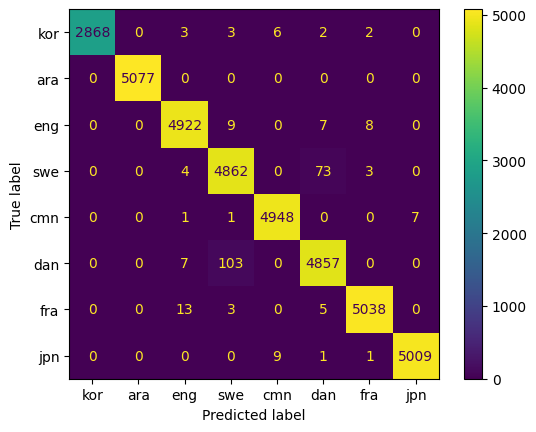

In [245]:
disp = ConfusionMatrixDisplay(confusion_matrix(
    y_val, y_val_pred), display_labels=display_labels)
disp.plot()

You may try to increase the number of iterations to improve the score. You may also try change the parameters of the multilayer percetron.


## Predict the language of a text


Now you will predict the languages of the strings below.


In [246]:
docs = ["Salut les gars !", "Hejsan grabbar!", "Hello guys!", "Hejsan tjejer!"]

In [247]:
build_freq_dict('Salut les gars !')

{331: 0.1875,
 234: 0.125,
 15: 0.125,
 69: 0.0625,
 432: 0.0625,
 86: 0.1875,
 32: 0.0625,
 31: 0.0625,
 437: 0.0625,
 333: 0.0625,
 1078: 0.06666666666666667,
 640: 0.06666666666666667,
 582: 0.06666666666666667,
 1542: 0.06666666666666667,
 1492: 0.06666666666666667,
 900: 0.06666666666666667,
 739: 0.06666666666666667,
 1319: 0.06666666666666667,
 1238: 0.13333333333333333,
 982: 0.06666666666666667,
 1415: 0.06666666666666667,
 557: 0.06666666666666667,
 1161: 0.06666666666666667,
 1020: 0.06666666666666667,
 1803: 0.07142857142857142,
 1608: 0.07142857142857142,
 2199: 0.07142857142857142,
 2349: 0.07142857142857142,
 2284: 0.07142857142857142,
 1958: 0.07142857142857142,
 1720: 0.07142857142857142,
 1925: 0.07142857142857142,
 2370: 0.07142857142857142,
 2546: 0.07142857142857142,
 1752: 0.07142857142857142,
 1805: 0.07142857142857142,
 1670: 0.07142857142857142,
 2269: 0.07142857142857142}

Create features vectors from this list. Call this matrix `X_test`


In [248]:
# Write your code here
X_test = vectorizer.transform([build_freq_dict(doc) for doc in docs])

In [249]:
X_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

And run the prediction that you will store in a variable called `pred_languages`


In [252]:
# Write your code here
pred_languages = model.predict(X_test)
pred_languages = [idx2lang[idx] for idx in pred_languages]

In [253]:
pred_languages

['fra', 'swe', 'eng', 'dan']

We save the model of our nano language detector to be able to reuse it for prediction


In [254]:
joblib.dump(clf, 'nld.joblib'), joblib.dump(
    vectorizer, 'nld_vectorizer.joblib'), joblib.dump(idx2lang, 'nld_lang_codes.joblib')

(['nld.joblib'], ['nld_vectorizer.joblib'], ['nld_lang_codes.joblib'])

## Building the Model with PyTorch

You will now recreate a PyTorch model with the same architecture as in sklearn.


### The Model

Create a model identical to the one you created with sklearn. Use the same activation function for the hidden layer and no activation in the last layer. Use the `Sequential` class.


In [255]:
input_dim = X.shape[1]
nbr_classes = len(langs)

In [257]:
# Write your code here

model = nn.Sequential(
  nn.Linear(input_dim, 50),
  nn.ReLU(),
  nn.Linear(50, nbr_classes)
)

In [258]:
model

Sequential(
  (0): Linear(in_features=2583, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=8, bias=True)
)

Write the loss `loss_fn` and optimizer `optimizer`. As optimizer, use the same as in sklearn. See here: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html


In [259]:
# Write your code here. (The solution is given)
loss_fn = nn.CrossEntropyLoss()    # cross entropy loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### The data loader


We convert the data to tensors


In [260]:
X_train = torch.Tensor(X_train)
y_train = torch.LongTensor(y_train)

X_val = torch.Tensor(X_val)
y_val = torch.LongTensor(y_val)

X_test = torch.Tensor(X_test)

In [261]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = TensorDataset(X_val, y_val)
val_dataloader = DataLoader(val_dataset, batch_size=32)

In [262]:
model.train()

Sequential(
  (0): Linear(in_features=2583, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=8, bias=True)
)

Fit your network on your training set. Write a code similar to that seen during the lecture and use five to seven epochs to start with. You will store the training and validation losses, `ce_train_loss`, `ce_val_loss`, in a list so that you can plot them


In [263]:
# Write your code here
ce_train_loss = []
ce_val_loss = []
for epoch in tqdm(range(7)):
    model.train()
    total_loss = 0
    for xb, yb in train_dataloader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_dataloader)
    ce_train_loss.append(avg_loss)
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for xb, yb in val_dataloader:
            preds = model(xb)
            loss = loss_fn(preds, yb)
            total_val_loss += loss.item()
        avg_val_loss = total_val_loss / len(val_dataloader)
        ce_val_loss.append(avg_val_loss)

100%|██████████| 7/7 [00:28<00:00,  4.04s/it]


In [264]:
ce_train_loss, ce_val_loss

([0.15330599891829644,
  0.018501217850093253,
  0.01274890950118699,
  0.010041376538096974,
  0.00856860645813905,
  0.0072983682295534565,
  0.006396841176002795],
 [0.02743392661505651,
  0.021500921876170035,
  0.02042166060120726,
  0.02092414513419302,
  0.02103792504650971,
  0.022323016046322388,
  0.023288756677373658])

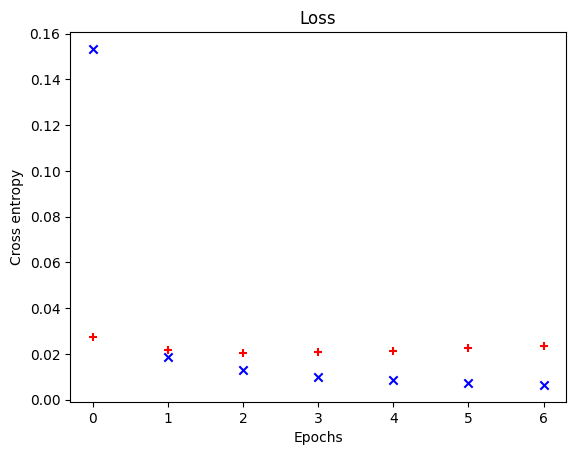

In [266]:
import matplotlib.pyplot as plt

plt.scatter(range(len(ce_train_loss)),
            ce_train_loss, c='b', marker='x')
plt.scatter(range(len(ce_train_loss)),
            ce_val_loss, c='r', marker='+')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross entropy')
plt.show()

Predict the validation set `X_val` in the form of logits. Call the result: `Y_val_pred_logits`


In [267]:
model.eval()

Sequential(
  (0): Linear(in_features=2583, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=8, bias=True)
)

In [268]:
# Write your code here
Y_val_pred_logits = model(X_val)

In [269]:
Y_val_pred_logits[:5]

tensor([[ -7.0912,  -7.9286,  -7.4946,  -7.2394,  -6.6861,  -7.2352,  14.6053,
          -9.2920],
        [ -7.0792,  -3.1468, -15.4618, -13.5856,  -6.5070, -16.0030, -10.1091,
          25.8469],
        [ -6.6753,  -7.4814,  14.3155,  -7.5555,  -5.5804,  -1.4862,  -8.9829,
         -11.3922],
        [ -4.5882,  -2.8972, -11.2402, -17.4963,  -1.1794, -10.5573,  -8.7456,
          19.1624],
        [ 15.5490,  -3.9718,  -7.8624, -10.4635,  -2.5867, -12.1193, -10.2566,
          -4.0114]], grad_fn=<SliceBackward0>)

Predict the validation set `X_val` in the form of probabilities. Use `torch.softmax()` for that and call the result: `Y_val_pred_proba`


In [270]:
# Write your code here
Y_val_pred_proba = F.softmax(Y_val_pred_logits, dim=1)

In [271]:
Y_val_pred_proba[:4]

tensor([[3.7788e-10, 1.6355e-10, 2.5243e-10, 3.2581e-10, 5.6658e-10, 3.2719e-10,
         1.0000e+00, 4.1834e-11],
        [5.0162e-15, 2.5598e-13, 1.1478e-18, 7.4939e-18, 8.8897e-15, 6.6812e-19,
         2.4239e-16, 1.0000e+00],
        [7.6525e-10, 3.4176e-10, 1.0000e+00, 3.1736e-10, 2.2873e-09, 1.3722e-07,
         7.6142e-11, 6.8438e-12],
        [4.8444e-11, 2.6283e-10, 6.2565e-14, 1.2005e-16, 1.4645e-09, 1.2386e-13,
         7.5814e-13, 1.0000e+00]], grad_fn=<SliceBackward0>)

Extract the categories from the probabilities in `Y_val_pred_proba`. Use the `torch.argmax()` function. Call the result `y_val_pred`. Check that the prediction corresponds to the real values.


In [276]:
# Write your code here
y_val_pred = torch.argmax(Y_val_pred_proba, dim=1)

In [277]:
y_val_pred[:20]

tensor([6, 7, 2, 7, 0, 3, 2, 5, 4, 5, 4, 4, 3, 4, 2, 3, 2, 2, 5, 7])

In [278]:
y_val[:20]

tensor([6, 7, 2, 7, 0, 3, 2, 5, 4, 5, 4, 4, 3, 4, 2, 3, 2, 2, 5, 7])

Print the evaluation


In [279]:
print(classification_report(y_val, y_val_pred, target_names=y_symbols))
print('Micro F1:', f1_score(y_val, y_val_pred, average='micro'))
print('Macro F1', f1_score(y_val, y_val_pred, average='macro'))

              precision    recall  f1-score   support

         kor       1.00      0.99      1.00      2884
         ara       1.00      1.00      1.00      5077
         eng       1.00      1.00      1.00      4946
         swe       0.99      0.98      0.98      4942
         cmn       1.00      1.00      1.00      4957
         dan       0.98      0.99      0.98      4967
         fra       1.00      1.00      1.00      5059
         jpn       1.00      1.00      1.00      5020

    accuracy                           0.99     37852
   macro avg       0.99      0.99      0.99     37852
weighted avg       0.99      0.99      0.99     37852

Micro F1: 0.9938972841593575
Macro F1 0.9940339784259328


Print the confusion matrix


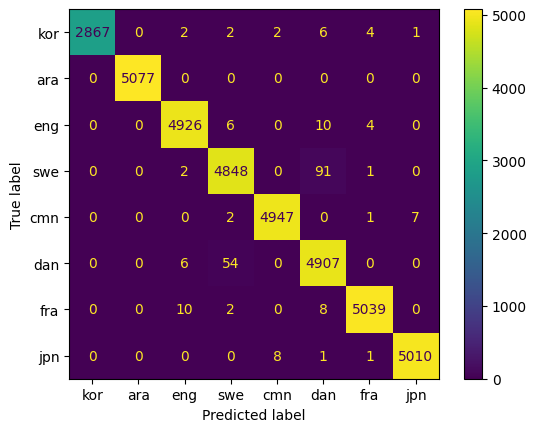

In [280]:
disp = ConfusionMatrixDisplay(confusion_matrix(
    y_val, y_val_pred), display_labels=display_labels)
disp.plot()

Predict your languages with PyTorch. Reuse `X_test` and call the result `Y_test_pred_proba`.


In [281]:
# Write your code here
Y_test_pred_proba = model(X_test)

In [282]:
Y_test_pred_proba

tensor([[ -6.6574,  -7.2358,  -2.6896,  -4.4331,  -9.1425,  -9.5248,  11.3607,
          -8.5325],
        [ -5.3733,  -7.7968,  -7.5103,   5.1236,  -5.1801,  -4.6815,  -6.9094,
         -11.4565],
        [ -6.0309,  -7.7621,   4.2691,  -7.1462,  -5.0818,  -0.4906,  -3.6167,
         -11.1379],
        [ -7.9505,  -7.4490, -13.0619,  -3.6624,  -6.0596,   7.0155,  -5.4666,
         -11.2842]], grad_fn=<AddmmBackward0>)

From the probabilities, extract the predicted languages and map them to strings. Call the results `pred_languages_pytorch`.


In [283]:
# Write your code here
pred_languages_pytorch = torch.argmax(Y_test_pred_proba, dim=1)
pred_languages_pytorch = [idx2lang[idx.item()] for idx in pred_languages_pytorch]

In [284]:
pred_languages_pytorch

['fra', 'swe', 'eng', 'dan']

We save the nano language detector


In [285]:
torch.save(model.state_dict(), 'nld.pth')

## Turning in your assignment


Now your are done with the program. To complete this assignment, you will write a report where you will:

1. Write a short individual report on your program. I recommend that you use this structure for your report:
   1. Objectives and dataset
   2. Method and program structure, where you should outline your program and possibly describe difficult parts.
   3. Results. Include the confusion matrix.
   4. Conclusion. As ideas for possible improvements, you may have a look at this paper: https://arxiv.org/pdf/2205.03983
2. In Sect. _Method and program structure_, do not forget to:
   - Summarize CLD3 and outline its architecture
   - Identify the features used by CLD3. Include the small matrix that you created with the _banana_ counts in the beginning of the notebook to illustrate the features.
   - Describe your architecture and tell how it is different from CLD3
   - Outline the differences between a sklearn and PyTorch program

The whole report should be of 2 to 3 pages.

Submit your report as well as your **notebook** (for archiving purposes) to Canvas: https://canvas.education.lu.se/. To write your report, use Latex. This will probably help you structure your text. You can use the Overleaf online editor (www.overleaf.com). You will then upload a PDF file in Canvas.

The submission deadline is October 10, 2025. You will have only three submission attempts. The deadline for the second and third ones are one week after you are noticed of your result.


## Postscript from Pierre Nugues


I created this assignment from an examination I wrote in 2019 for the course on applied machine learning. I simplified it from the `README.md` on GitHub, https://github.com/google/cld3. I found the C++ code difficult to understand and I reimplemented a Keras/Tensorflow version of it from this `README`. Should you be interested, you can find it here: https://github.com/pnugues/language-detector.
